In [1]:
import sys
import time
import pathlib
cur_path = pathlib.Path().resolve().parent.absolute()
src_loc = cur_path.joinpath("src")
util_loc = src_loc.joinpath("utils")
sys.path.append(str(cur_path))
sys.path.append(str(src_loc))
sys.path.append(str(util_loc))

# 1 Load Data

### 1.1 Setup env and load packages

In [2]:
# load the libraries and initial settings
import os
import pathlib
import time
import datetime
import subprocess
import pyarrow as pa
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
from src.conf import Conf
from src.utils.utils import elapsed_time, save_data, load_data
from src.utils.sql import sql
# Load configuration
confparam_path = cur_path.joinpath("src", "conf", "conf_dev.yml")
dataparam_path = cur_path.joinpath("src", "data", "ctp_dbt_model", "dbt_project.yml")
conf = Conf(confparam_path, dataparam_path )
project_start_time = time.time()

### 1.2 query data from EDH

#### 1.2.1 Query node features

In [3]:
# query for customer relationship

cust_query="""
SELECT *
FROM dl_analytics.ctp_customer_connection_dbt
"""

# query for doctor&lawyer relationship

doc_lawyer_query="""
SELECT *
FROM dl_analytics.ctp_doctor_lawyer_pair_dbt
"""

# query for docotr&psych relationship

doc_psych_query="""
SELECT *
FROM dl_analytics.ctp_doctor_psych_pair_dbt
"""

# query for doctor&repairer relationship

doc_repair_query="""
SELECT *
FROM dl_analytics.ctp_doctor_repairer_pair_dbt
"""

# query for payment relationship

payment_query="""
SELECT *
FROM dl_analytics.ctp_payment_connection_dbt
"""

# query for vehicle relationship

vehicle_query="""
SELECT *
FROM dl_analytics.ctp_vehicle_connection_dbt
"""

In [4]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
cust_df = sql( conf=conf, fn="get", sql=cust_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.240
Total elapsed time: 0:0:01.269


In [5]:
# Check for duplicates based on all columns
print('*'*60)
print("check duplicates")
duplicates = cust_df[cust_df.duplicated()]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(cust_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 7452
Number of duplicates is 0


In [6]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_lawyer_df = sql( conf=conf, fn="get", sql=doc_lawyer_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.379
Total elapsed time: 0:0:02.790


In [7]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_psych_df = sql(conf=conf, fn="get", sql=doc_psych_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.407
Total elapsed time: 0:0:04.215


In [8]:
doc_psych_df

,claim_number_1,claim_number_2
0,NWRTP2301761,NWRTP2002774
1,NWRTP2001152,NWRTP2302719
2,NWRTP2100537,NWRTP2002355
3,NWRTP2100537,NWRTP2301246
4,NWRTP1801448,NWRTP2300059
...,...,...
9503,NWRTP2303000,NWRTP2100337
9504,NWRTP2303000,NWRTP2100591
9505,NWRTP2100337,NWRTP2100591
9506,NWRND1900137,NWRTP1901761


In [9]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
doc_repair_df = sql(conf=conf, fn="get", sql=doc_repair_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.612
Total elapsed time: 0:0:05.914


In [10]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
payment_df = sql(conf=conf, fn="get", sql=payment_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:5:11.559
Total elapsed time: 0:5:17.501


In [11]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
vehicle_df = sql(conf=conf, fn="get", sql=vehicle_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:03.675
Total elapsed time: 0:5:21.212


In [12]:
vehicle_df.shape

(465992, 2)

#### 1.2.2 Query node features

In [5]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
node_query='SELECT * FROM dl_analytics.ctp_node_features_dbt'
node_df = sql(conf=conf, fn="get", sql=node_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.494
Total elapsed time: 2:23:23.571


In [6]:
node_df

,claim_number,claim_lodgement_date,claim_loss_date,score,predicted_anomaly_flag,contributing_factors,contributing_factors_shap,insert_timestamp
0,NWRND2300171,2023-08-10,2023-08-01,0.146,False,cause of loss name: 99 Unknown | police involv...,cause of loss name: 1.06 | police involved : 0...,2025-01-20 22:43:15
1,NWRND2300241,2023-12-01,2023-10-07,0.115,False,max number of fitness certificate : 12.0 | psy...,max number of fitness certificate : 1.02 | psy...,2025-01-20 22:43:15
2,NWRTP2300920,2023-04-27,2023-01-27,0.094,False,psychological claim: True | duration between l...,psychological claim: 1.1 | duration between lo...,2025-01-20 22:43:15
3,NWRTP2302286,2023-09-20,2023-09-12,0.049,False,max number of fitness certificate : 17.0 | cau...,max number of fitness certificate : 1.23 | cau...,2025-01-20 22:43:15
4,NWRTP2302657,2023-11-01,2023-10-21,0.060,False,claiment is self employed: True | Over all pol...,claiment is self employed: 1.66 | Over all pol...,2025-01-20 22:43:15
...,...,...,...,...,...,...,...,...
4531,NWRTP2403341,2024-12-05,2024-11-29,0.142,False,police involved : False | cause of loss name: ...,police involved : 1.07 | cause of loss name: 0...,2025-01-20 22:43:15
4532,NWRTP2403473,2024-12-19,2024-10-13,0.157,False,police involved : False | proportion of non-th...,police involved : 1.35 | proportion of non-thr...,2025-01-20 22:43:15
4533,NWRTP2403557,2024-12-31,2024-12-29,0.163,False,police involved : False | proportion of non-th...,police involved : 1.2 | proportion of non-thre...,2025-01-20 22:43:15
4534,NWRTP2500067,2025-01-09,2025-01-02,0.149,False,"Over all policy holders, minimum number of day...","Over all policy holders, minimum number of day...",2025-01-20 22:43:15


In [15]:
# Check for duplicates based on claim number
print('*'*60)
print("check duplicates")
duplicates = node_df[node_df.duplicated(subset=['claim_number'])]
num_duplicates = len(duplicates)

print("Original sample size is {}\nNumber of duplicates is {}".format(node_df.shape[0], num_duplicates))

************************************************************
check duplicates
Original sample size is 19989
Number of duplicates is 849


In [8]:
print('*' * 60)
print("Data query started ...")
function_start_time = time.time()
# fraud_query="SELECT * FROM dl_analytics.claim_mr1118_ctp1_anomaly_detection_scores WHERE predicted_anomaly_flag ='True' "
fraud_query="SELECT * FROM dl_analytics.claim_mr1118_ctp1_anomaly_detection_scores "
# fraud_query="SELECT * FROM dl_analytics.claim_mr1118_ctp1_anomaly_detection_scores"
fraud_df = sql(conf=conf, fn="get", sql=fraud_query)
print('*'*60)
print("data query finished")
elapsed_time('Query data from EDH', project_start_time, function_start_time)

************************************************************
Data query started ...
************************************************************
data query finished

Elapsed time (Query data from EDH): 0:0:01.241
Total elapsed time: 6:3:48.134


In [9]:
fraud_df

,claim_number,claim_lodgement_date,claim_loss_date,score,predicted_anomaly_flag,investigation_flag,linked_investigated_claims,linked_customer_name,contributing_factors,contributing_factors_shap,insert_timestamp
0,NWRND2300171,2023-08-10,2023-08-01,0.146,False,False,,,cause of loss name: 99 Unknown | police involv...,cause of loss name: 1.06 | police involved : 0...,2025-01-29 15:23:08
1,NWRND2300241,2023-12-01,2023-10-07,0.107,False,False,,,max number of fitness certificate : 13.0 | psy...,max number of fitness certificate : 1.17 | psy...,2025-01-29 15:23:08
2,NWRTP2300920,2023-04-27,2023-01-27,0.094,False,False,,,psychological claim: True | duration between l...,psychological claim: 1.1 | duration between lo...,2025-01-29 15:23:08
3,NWRTP2302286,2023-09-20,2023-09-12,0.049,False,False,,,max number of fitness certificate : 17.0 | cau...,max number of fitness certificate : 1.23 | cau...,2025-01-29 15:23:08
4,NWRTP2302657,2023-11-01,2023-10-21,0.060,False,False,,,claiment is self employed: True | Over all pol...,claiment is self employed: 1.66 | Over all pol...,2025-01-29 15:23:08
...,...,...,...,...,...,...,...,...,...,...,...
4550,NWRTP2403269,2024-11-29,2024-11-27,0.173,False,False,,,max number of fitness certificate : 7.0 | mino...,max number of fitness certificate : 0.506 | mi...,2025-01-29 15:23:08
4551,NWRTP2500149,2025-01-20,2024-06-22,0.107,False,False,,,cause of loss name: 29 Other opposing | police...,cause of loss name: 1.29 | police involved : 1...,2025-01-29 15:23:08
4552,NWRTP2403048,2024-11-08,2024-10-27,0.065,False,False,,,cause of loss name: 29 Other opposing | police...,cause of loss name: 1.31 | police involved : 1...,2025-01-29 15:23:08
4553,NWRTP2500089,2025-01-13,2025-01-07,0.156,False,False,,,number of not threshold injuries: 2.0 | propor...,number of not threshold injuries: 1.7 | propor...,2025-01-29 15:23:08


In [11]:
fraud_df.to_csv("anomaly_score_output.csv", index=False)

### 1.3 create pa schema and save parquet

In [19]:
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(cust_df)
# save data 
save_data(cust_df, conf.data_path, 'customer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_lawyer_df)
# save data 
save_data(doc_lawyer_df, conf.data_path, 'doc_lawyer_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_psych_df)
# save data 
save_data(doc_psych_df, conf.data_path, 'doc_psych_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(doc_repair_df)
# save data 
save_data(doc_repair_df, conf.data_path, 'doc_repair_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(payment_df)
# save data 
save_data(payment_df, conf.data_path, 'payment_connection_data', data_extension='parquet', schema=new_schema)
# Generate PyArrow schema based on DataFrame data types
new_schema = pa.Schema.from_pandas(vehicle_df)
# save data 
save_data(vehicle_df, conf.data_path, 'vehicle_connection_data', data_extension='parquet', schema=new_schema)


Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\customer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\payment_connection_data.parquet
Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet


In [20]:
# save claim node data
new_schema = pa.Schema.from_pandas(node_df)
save_data(node_df, conf.data_path, 'node_feature', data_extension='parquet', schema=new_schema)

Data saved successfully locally as Parquet: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet


# 2 Data preprocessing

### 2.1 load data locally

In [21]:
import decimal
from scipy import sparse
from category_encoders import BinaryEncoder
import torch
from torch_geometric.data import Data
import numpy as np 
import pandas as pd
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [22]:
project_start_time = time.time()

print('*' * 60)
print("load data locally ...")

function_start_time = time.time()
cust_df=load_data(conf.data_path, 'customer_connection_data',  data_extension='parquet')
doc_lawyer_df=load_data(conf.data_path, 'doc_lawyer_connection_data',  data_extension='parquet')
doc_psych_df=load_data(conf.data_path, 'doc_psych_connection_data',  data_extension='parquet')
doc_repair_df=load_data(conf.data_path, 'doc_repair_connection_data',  data_extension='parquet')
payment_df=load_data(conf.data_path, 'payment_connection_data',  data_extension='parquet')
vehicle_df=load_data(conf.data_path, 'vehicle_connection_data',  data_extension='parquet')
node_df=load_data(conf.data_path, 'node_feature',  data_extension='parquet')

elapsed_time('load data', project_start_time, function_start_time)

************************************************************
load data locally ...
Loading data locally: C:\GitHub\CTP_syndicate_model\data\customer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_lawyer_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_psych_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\doc_repair_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\payment_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\vehicle_connection_data.parquet
Loading data locally: C:\GitHub\CTP_syndicate_model\data\node_feature.parquet

Elapsed time (load data): 0:0:11.103
Total elapsed time: 0:0:11.103


### 2.2 Node features engineering 

In [23]:
input_dataframe=node_df.copy()

In [24]:
def data_transformation(input_dataframe):
        """
        Function to perform data preparation steps on the given model_data DataFrame.

        Args:
        - input_dataframe: DataFrame containing the data to be prepared

        Returns:
        - model_data: DataFrame with the prepared data including node features
        """

        # Remove duplicates from input dataframe

        duplicates=input_dataframe.duplicated(['claim_number']).sum()

        if duplicates>0:
                input_dataframe = input_dataframe.drop_duplicates(subset=['claim_number'], keep='first')

        # Convert datatype to get over Decimal
        for x in list(input_dataframe.columns):
                if (input_dataframe[x].dtype == 'object') & (type(input_dataframe[x][0]) == decimal.Decimal):
                        input_dataframe[x] = input_dataframe[x].astype('float')
        # transfor timedelta to days              
        input_dataframe.loc[:,'max_late_treatment_days']=input_dataframe['max_late_treatment_days'].dt.days

        # fill the missing value
        fill_zero_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "self_employed_flag",
        "max_pre_accident_weekly_earning",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "late_report_police_days",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag"
        ]
        for x in fill_zero_cols:
                input_dataframe[x].fillna(0, inplace=True)


        fill_max_cols=["cause_of_loss_name"]
        for x in fill_max_cols:
                # Replace empty strings with NaN
                input_dataframe[x].replace('', pd.NA, inplace=True)
                # Fill NaN with 'missing'
                input_dataframe[x].fillna('62 Accident', inplace=True)

        # Grouping categories of cause of loss name with count less than 50 as 'Others'
        input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(
        lambda x: x if input_dataframe['cause_of_loss_name'].value_counts()[x] >= 100 else 'Others')


        # Column Selection
        # binary_features
        binary_cols = ["cause_of_loss_name"]
        # Numeric columns
        num_cols = [
        "late_lodgement_days",
        "late_report_days",
        "max_late_treatment_days",
        "max_amt_fitness_certificate_per_exp",
        "cust_max_investigation_count",
        "cust_max_denial_count",
        "cust_max_ctp_claim_count_total",
        "cust_min_last_cancel_arrear_days",
        "max_days_of_minor_assess_to_lodgement",
        "not_threshold_injury_amt",
        "proportion_of_not_threshold_injury",
        "not_attend_hospital_immediately_amt",
        "not_injured_is_only_insured_driver",
        "max_days_late_recovery_from_loss",
        "max_pre_accident_weekly_earning",
        "late_report_police_days"
        ]
        #One hot encodin
        ohe_cols = [
        "self_employed_flag",
        "not_fit_for_work_flag",
        "off_work_minor_injury_flag",
        "suspacious_not_working_flag",
        "police_involved_flag",
        "ambulance_attendance_flag",
        "accident_injury_mismatch_flag",
        "psych_claim_flag"
        ""
        ]
        #id_columns
        id_cols = ['claim_number']

        features=  num_cols + ohe_cols+ binary_cols

        # Initialize the BinaryEncoder for binary cols
        encoder = BinaryEncoder(cols=['cause_of_loss_name'])

        # Fit and transform the 'cause_of_loss_name' column in the DataFrame
        df_encoded = encoder.fit_transform(input_dataframe)

        df_encoded[ohe_cols]=df_encoded[ohe_cols].astype(int)
        return df_encoded

In [25]:
# perform data processing and engineering
df_encoded=data_transformation(input_dataframe)
df_encoded.info()

C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\922250236.py:54: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].fillna(0, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\922250236.py:60: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe[x].replace('', pd.NA, inplace=True)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\922250236.py:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
 

<class 'pandas.core.frame.DataFrame'>
Index: 19140 entries, 0 to 19988
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   late_lodgement_days                    19140 non-null  int64  
 1   late_report_days                       19140 non-null  int64  
 2   cause_of_loss_name_0                   19140 non-null  int64  
 3   cause_of_loss_name_1                   19140 non-null  int64  
 4   cause_of_loss_name_2                   19140 non-null  int64  
 5   cause_of_loss_name_3                   19140 non-null  int64  
 6   cause_of_loss_name_4                   19140 non-null  int64  
 7   max_late_treatment_days                19140 non-null  float64
 8   max_amt_fitness_certificate_per_exp    19140 non-null  float64
 9   cust_max_investigation_count           19140 non-null  float64
 10  cust_max_denial_count                  19140 non-null  float64
 11  cust_ma

C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\922250236.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  input_dataframe['cause_of_loss_name'] = input_dataframe['cause_of_loss_name'].apply(


### 2.3 Build CTP Claim Network

In [26]:
# Assign a weight of 1 to each edge in each dataframe
cust_df['weight'] = 1 
doc_lawyer_df['weight'] = 1
doc_psych_df['weight'] = 1
doc_repair_df['weight'] = 1
payment_df['weight'] = 1
vehicle_df['weight'] = 1


In [27]:
# concatnate all different type of edges
edges_all=pd.concat([cust_df,doc_lawyer_df,doc_psych_df,doc_repair_df,vehicle_df], ignore_index=True)
#For undirected graphs, sort the node IDs in each edge to treat (u, v) and (v, u) as the same
# edges_all['edge']=edges_all.apply(lambda row: tuple(sorted([row['claim_number_1'], row['claim_number_2']])), axis=1)
edges_all['edge']=edges_all.apply(lambda row: tuple([row['claim_number_1'], row['claim_number_2']]), axis=1)

 #Group by 'edge' and sum the weights
edges_grouped=edges_all.groupby('edge').agg({'weight':sum}).reset_index()

#Split 'edge' back into 'source' and 'target'
edges_grouped[['source', 'target']] = pd.DataFrame(edges_grouped['edge'].tolist(), index=edges_grouped.index)
edges_grouped = edges_grouped.drop(columns='edge')
edges_grouped

,weight,source,target
0,1,NWRND1800081,NWRND1800084
1,1,NWRND1800081,NWRND1800085
2,1,NWRND1800081,NWRND1800087
3,1,NWRND1800081,NWRND1800089
4,1,NWRND1800081,NWRND1800092
...,...,...,...
512493,2,NWRTP2400801,NWRTP2400800
512494,1,NWRTP2400805,NWRTP2102259
512495,1,NWRTP2400806,NWRTP1802554
512496,1,NWRTP2400806,NWRTP2300703


In [28]:
# Create a mapping from node IDs to indices, including all nodes from df_node_features
# Extract node IDs from edges
edge_node_ids = set(edges_grouped['source']).union(edges_grouped['target'])

# Extract node IDs from node features
feature_node_ids = set(df_encoded['claim_number'])

# Union of all node IDs
all_node_ids = edge_node_ids.union(feature_node_ids)

# Create mapping from node IDs to indices
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(sorted(all_node_ids))}


In [29]:
edge_node_ids.issubset(feature_node_ids)

True

In [30]:
# Map claim number to indices in edges
edges_grouped['source_idx'] = edges_grouped['source'].map(node_id_to_idx)
edges_grouped['target_idx'] = edges_grouped['target'].map(node_id_to_idx)
# Prepare node features, including nodes without edges
df_encoded['node_idx'] = df_encoded['claim_number'].map(node_id_to_idx)

all_nodes_df = df_encoded.sort_values('node_idx')
all_nodes_df

,late_lodgement_days,late_report_days,cause_of_loss_name_0,cause_of_loss_name_1,cause_of_loss_name_2,cause_of_loss_name_3,cause_of_loss_name_4,max_late_treatment_days,max_amt_fitness_certificate_per_exp,cust_max_investigation_count,...,suspacious_not_working_flag,police_involved_flag,late_report_police_days,ambulance_attendance_flag,accident_injury_mismatch_flag,psych_claim_flag,investigation_flag,triage_flag,claim_number,node_idx
14933,19,19,0,0,1,0,0,19.000,1.000,0.000,...,1,1,0.000,0,0,0,0,0,NWRND1800081,0
3466,50,50,0,1,0,0,1,0.000,1.000,0.000,...,1,1,0.000,0,0,0,0,0,NWRND1800082,1
12929,52,52,0,0,1,0,0,1.000,1.000,0.000,...,1,1,0.000,1,0,0,0,0,NWRND1800083,2
15781,96,96,1,0,1,1,0,0.000,1.000,0.000,...,0,1,0.000,1,0,0,0,0,NWRND1800084,3
15988,40,40,0,0,1,1,1,0.000,0.000,0.000,...,1,1,0.000,1,0,0,0,0,NWRND1800085,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11006,209,209,0,0,0,0,1,296.000,4.000,0.000,...,0,0,0.000,0,0,1,0,0,NWRTP2400802,19135
4305,1,1,0,0,0,1,0,121.000,12.000,0.000,...,1,1,4.000,0,0,1,0,0,NWRTP2400803,19136
10964,7,7,0,0,0,0,1,111.000,8.000,0.000,...,0,1,0.000,0,0,0,0,0,NWRTP2400804,19137
3160,4,4,0,0,0,0,1,44.000,2.000,0.000,...,0,0,0.000,0,0,0,0,0,NWRTP2400805,19138


In [31]:
feature_cols=df_encoded.columns.drop(['claim_number', 'node_idx', 'investigation_flag','triage_flag'])
feature_cols

Index(['late_lodgement_days', 'late_report_days', 'cause_of_loss_name_0',
       'cause_of_loss_name_1', 'cause_of_loss_name_2', 'cause_of_loss_name_3',
       'cause_of_loss_name_4', 'max_late_treatment_days',
       'max_amt_fitness_certificate_per_exp', 'cust_max_investigation_count',
       'cust_max_denial_count', 'cust_max_ctp_claim_count_total',
       'cust_min_last_cancel_arrear_days',
       'max_days_of_minor_assess_to_lodgement', 'not_threshold_injury_amt',
       'proportion_of_not_threshold_injury',
       'not_attend_hospital_immediately_amt',
       'not_injured_is_only_insured_driver',
       'max_days_late_recovery_from_loss', 'self_employed_flag',
       'max_pre_accident_weekly_earning', 'not_fit_for_work_flag',
       'off_work_minor_injury_flag', 'suspacious_not_working_flag',
       'police_involved_flag', 'late_report_police_days',
       'ambulance_attendance_flag', 'accident_injury_mismatch_flag',
       'psych_claim_flag'],
      dtype='object')

In [32]:
# Extract node features as a tensor
x=torch.tensor(all_nodes_df[feature_cols].values,dtype=torch.float)
# Create edge_index tensor
edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)
# Create edge_weight tensor
edge_weight = torch.tensor(edges_grouped['weight'].values, dtype=torch.float)
# Create investigation label tensor
y = torch.tensor(all_nodes_df['investigation_flag'].values, dtype=torch.long)

C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2710482895.py:4: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\torch\csrc\utils\tensor_new.cpp:281.)
  edge_index = torch.tensor([edges_grouped['source_idx'].values, edges_grouped['target_idx'].values], dtype=torch.long)


In [33]:
# Create PyG data object as CTP claim network
data = Data(x=x, edge_index=edge_index, edge_weight=edge_weight, y=y)
data

Data(x=[19140, 29], edge_index=[2, 512498], y=[19140], edge_weight=[512498])

### 2.4 Visualize the Network

In [34]:
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

In [35]:
# # Convert PyG object to networkx data object
G = to_networkx(data, node_attrs=['x', 'y'], edge_attrs=['edge_weight'], to_undirected=True)
# nx.number_of_edges(G)
# # Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# color_map = []
# for node in G.nodes(data=True):
#     if node[1]['y'] == 0:  # Node label is 0
#         color_map.append('red')
#     else:  # Node label is 1
#         color_map.append('blue')
# # Draw the graph using the color map
# # pos = nx.kamada_kawai_layout(G) 
# pos = nx.spring_layout(G)# Use spring layout for better visual separation

# plt.figure(figsize=(10, 8))
# nx.draw(G, pos, node_color=color_map, with_labels=True, node_size=50, font_color='white', font_weight='bold')
# plt.show()

In [36]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 19140
Number of edges: 256249


In [37]:
import random
# Define the number of nodes to sample
num_nodes_to_sample = 1000  # Adjust based on your requirements

# Randomly sample nodes
sampled_nodes = random.sample(list(G.nodes()), min(num_nodes_to_sample, num_nodes))

# Create a subgraph with the sampled nodes
G_sub = G.subgraph(sampled_nodes)

In [38]:
# # Filter nodes with degree greater than a threshold
# degree_threshold = 10
# nodes_to_keep = [node for node, degree in G.degree() if degree > degree_threshold]
# G_sub = G.subgraph(nodes_to_keep)

In [39]:
num_nodes = G_sub.number_of_nodes()
num_edges = G_sub.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 1000
Number of edges: 596


In [40]:
color_map = []
count=0
for node in G_sub.nodes(data=True):
    if node[1]['y'] == 1:  # Node label is 0
        color_map.append('red')
        count+=1
    else:  # Node label is 1
        color_map.append('blue')
count

10

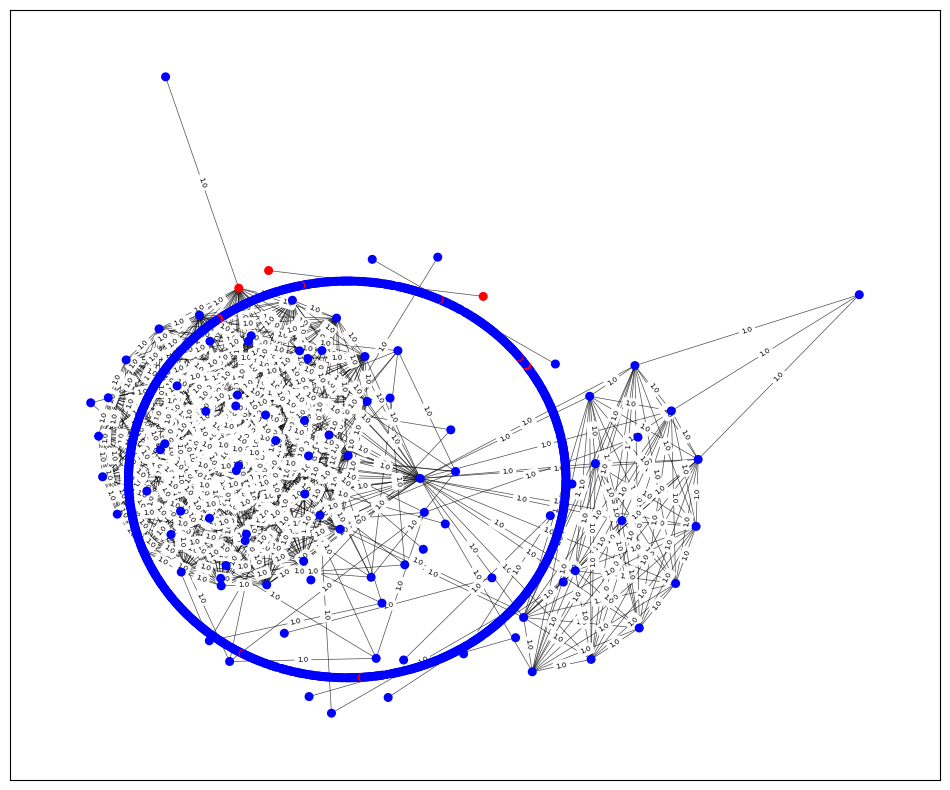

In [41]:
# Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# Draw the graph using the color map
pos = nx.kamada_kawai_layout(G_sub) 
# pos = nx.spring_layout(G_sub,seed=42)# Use spring layout for better visual separation
# pos = nx.random_layout(G_sub) 


plt.figure(figsize=(12, 10))
node_options={"node_color":color_map, "node_size":30}
edge_options={"width": 0.5, "alpha":.7, "edge_color": "black"}
edge_labels = {(u, v): round(d['edge_weight'], 0) for u, v, d in G_sub.edges(data=True)}

nx.draw_networkx_nodes(G_sub, pos, **node_options)
nx.draw_networkx_edges(G_sub, pos, **edge_options)
nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=5)
plt.show()

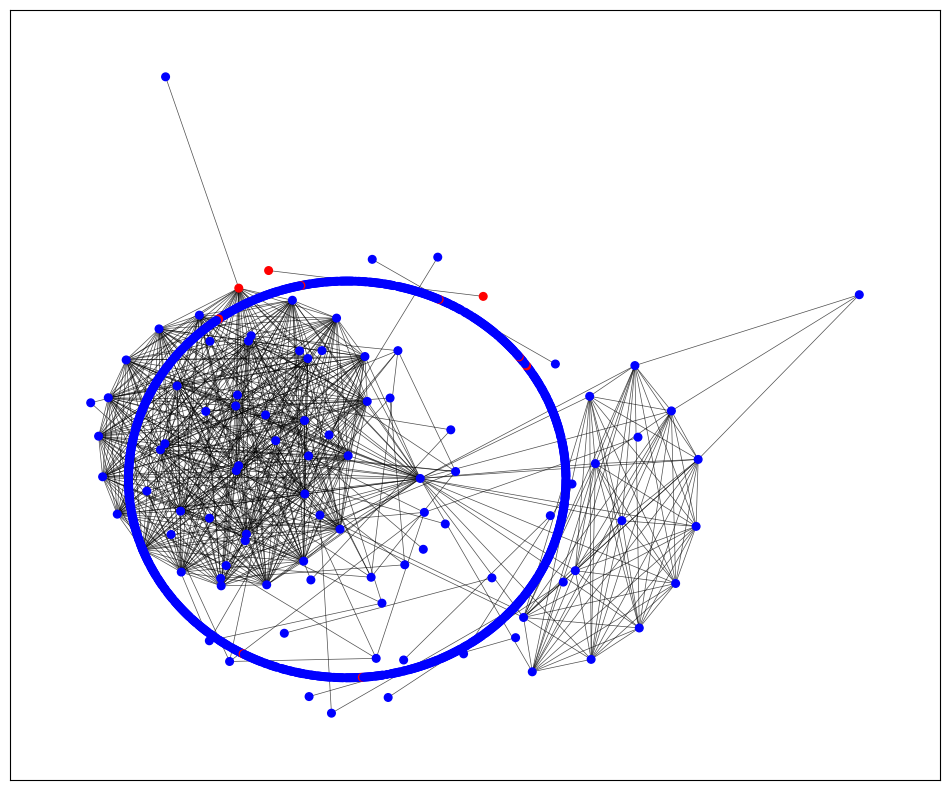

In [42]:
# Create a color map: assign one color to nodes with label 0, another to nodes with label 1
# Draw the graph using the color map
pos = nx.kamada_kawai_layout(G_sub) 
# pos = nx.spring_layout(G_sub,seed=42)# Use spring layout for better visual separation
# pos = nx.random_layout(G_sub) 


plt.figure(figsize=(12, 10))
node_options={"node_color":color_map, "node_size":30}
edge_options={"width": 0.5, "alpha":.7, "edge_color": "black"}
# edge_labels = {(u, v): round(d['edge_weight']/2, 1) for u, v, d in G_sub.edges(data=True)}

nx.draw_networkx_nodes(G_sub, pos, **node_options)
nx.draw_networkx_edges(G_sub, pos, **edge_options)
# nx.draw_networkx_edge_labels(G_sub, pos, edge_labels=edge_labels, font_size=5)
plt.show()

In [43]:
from torch_geometric.utils import degree

edge_index = data.edge_index
num_nodes = data.num_nodes

# Calculate the degree of each node
node_degrees = degree(edge_index[0], num_nodes=num_nodes)
node_degrees

tensor([708.,   0.,   0.,  ...,   0.,   1.,   3.])

# 3 Implement algorithms on Claim Network

In [44]:
import pytz
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.metrics import precision_score, recall_score, \
    f1_score, confusion_matrix, auc, precision_recall_curve,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
# from pygod.detector import DOMINANT
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import negative_sampling
from torch_geometric.data import Data
from network import Dominant
import optuna

c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 3.1 Hyperparameter tuning on DOMINANT model

In [45]:
class networkEvaluator:
    """
    conf: from Conf class
    model_IF: isolation forest model
    x: input dataframe
    y: target value
    id_df: index columns of dataframe
    csv_filename: name of saving file
    thresh: threshold for model IF decision fucntion
    metric1: use as objective in HP, key in metrics dictionary
    metric2: use for comparison in plot, key in metrics dictionary
    """

    def __init__(self, conf):
        self.conf = conf

    @staticmethod
    def evaluate (conf, model, data, id_df, thresh, MODEL_TAG, csv_filename, metric1, metric2):
        anomaly_scores, y_emb=model.predict(data, get_emb=True)
        y_score = anomaly_scores.numpy()
        y_score = pd.Series(y_score, name='y_score')
        y_real= pd.Series(id_df['investigation_flag'], name='y')
        triage = pd.Series(id_df['triage_flag'], name='triage_flag')
        combined_df = pd.concat([y_score.reset_index(drop=True), 
                                 y_real.reset_index(drop=True), 
                                 triage.reset_index(drop=True)], axis=1)
        combined_df['y_pred'] = np.where(combined_df['y_score'] >= thresh, 1, 0)
        alert_vol =  sum(combined_df['y_pred'] == 1)
        inv_curr = sum(combined_df['y'])
        triage_curr = sum(combined_df['triage_flag'])

        t2i_curr = np.divide(inv_curr, triage_curr,
                                out=np.zeros_like(inv_curr, dtype=float), where=triage_curr != 0)

        inv_pred = sum(combined_df[combined_df['y_pred'] == 1]['y'])
        triage_pred = sum(combined_df[combined_df['y_pred'] == 1]['triage_flag'])

        t2i_pred = np.divide(inv_pred, triage_pred,
                                out=np.zeros_like(inv_pred, dtype=float), where=triage_pred != 0)
        
        precision = precision_score(combined_df['y'], combined_df['y_pred'])
        recall = recall_score(combined_df['y'], combined_df['y_pred'])
        f1 = f1_score(combined_df['y'], combined_df['y_pred'])
        conf_matrix = confusion_matrix(combined_df['y'], combined_df['y_pred'])
        precision2, recall2, _ = precision_recall_curve(combined_df['y'], combined_df['y_score'])
        pr_auc = auc(recall2, precision2)
        auc_roc_score = roc_auc_score(combined_df['y'], combined_df['y_score'])

        metrics = {
            "alert_vol": alert_vol,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "Confusion Matrix": conf_matrix,
            "AUC-PR": pr_auc,
            "AUC-ROC": auc_roc_score,
            "Current T2I": t2i_curr,
            "New T2I": t2i_pred
        }
        # Print metrics
        print("Evaluation Metrics:")
        for metric_name, metric_value in metrics.items():
            print(f"{metric_name}: {metric_value}")
        
        # Save meitrics to CSV
        networkEvaluator.save_metrics_to_csv(MODEL_TAG, metrics,
                                                     metric1, metric2, csv_filename)
        return metrics, combined_df

    @staticmethod
    def save_metrics_to_csv(MODEL_TAG, metrics, metric1, metric2, csv_filename):
        try:
            metric_df = pd.read_csv(csv_filename)
        except FileNotFoundError:
            metric_df = pd.DataFrame(columns=['Model', metric1, metric2])

        new_row = pd.DataFrame({'Model': [MODEL_TAG], 
                                metric1: [metrics[metric1]], 
                                metric2: [metrics[metric2]]})
        
        metric_df = pd.concat([metric_df, new_row], ignore_index=True)
        metric_df.to_csv(csv_filename, index=False)


# evaluator for Random forest 

In [46]:

class networkTrainer:
    """
    use metric1 as objective
    use metirc2 as comparison in plot

    """
    def __init__(self, conf, data, id_train, metric1, metric2):
        self.conf = conf
        self.data = data
        self.id_train = id_train
        self.metric1 = metric1
        self.metric2 = metric2
        self.metric_results = []

    def objective(self, trial):
        # Suggest values for the hyperparameters
        hidden_size = trial.suggest_int('hidden_size', 5, self.data.x.shape[1], step=1 )
        num_epochs = trial.suggest_int('num_epochs', 100, 200, step=5 )
        learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1) 
        weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
        dropout = trial.suggest_uniform('dropout', 0, 0.5) 
        # Create the model with suggested hyperparameters
        params={
            'hidden_size': hidden_size,
            'num_epochs': num_epochs,
            'learning_rate': learning_rate,
            'weight_decay': weight_decay,
            'dropout': 0
        }
        # threshold = trial.suggest_uniform('threshold', 0, 0.5)  # Optimize threshold
        MODEL_TAG = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
        model = self.train_model(self.data, params)
        metrics, combined_df = networkEvaluator.evaluate(self.conf, model, self.data, self.id_train, 
                        500, MODEL_TAG, self.conf.artefact_path + "/metrics_train.csv", 
                        self.metric1, self.metric2)
        # Save the metrics for later plotting
        self.metric_results.append({self.metric1:metrics[self.metric1], self.metric2:metrics[self.metric2]})
        return metrics[self.metric1]
    

    def train_model(self, data, params):
        model = Dominant(feat_size=data.x.shape[1], hidden_size=params['hidden_size'], dropout=params['dropout'])
        model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
        return model

    def train_with_optuna(self, n_trials=50):
        study = optuna.create_study(direction='maximize')
        study.optimize(self.objective, n_trials)  # 100 trials

        best_params = study.best_params

        # Plot A2I and "New R2I" curves after all trials are finished
        self.plot_metrics_curve()

        return best_params, study

    def plot_metrics_curve(self):
        # Retrieve the desired metrics from the results
        metric1_values = [result[self.metric1] for result in self.metric_results]
        metric2_values = [result[self.metric2] for result in self.metric_results]
        trials = np.arange(1, len(metric1_values) + 1)

        # Plot the selected metrics
        plt.figure(figsize=(10, 6))
        plt.plot(trials, metric1_values, marker='o', linestyle='-', color='b', label=self.metric1)
        plt.plot(trials, metric2_values, marker='o', linestyle='-', color='r', label=self.metric2)
        plt.title('Performance Metrics for Hyperparameter Tuning Trials')
        plt.xlabel('Trial')
        plt.ylabel('Score')
        plt.legend()
        plt.tight_layout()
        plt.show()

In [47]:
# init params
hptrial = 100 # number of trials in HP tuning
metric1 = 'New T2I' # use as objective in HP tuning
metric2 = 'AUC-PR'  # use for HP tuning tracking

# train_tag = datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')
print('*' * 60)
print('HP tuning started...')
# use New T2D as objective
# run on 2024-02-16
function_start_time = time.time()
# Instantiate the trainer
trainer = networkTrainer(conf, data, all_nodes_df, metric1, metric2)
# Train with Optuna
best_params, study = trainer.train_with_optuna(n_trials=hptrial)
trial_data = study.trials_dataframe()
# save_pkl(best_params, conf.artefact_path, "best_params", data_extension="pkl")
# save_pkl(trial_data, conf.artefact_path, "trial_data_{}".format(train_tag), data_extension="pkl")
print("Best Parameters:", best_params)
print('HP tuning finished...')
print('*' * 60)
elapsed_time('model HP tuning', project_start_time, function_start_time)

[I 2024-10-29 10:17:22,456] A new study created in memory with name: no-name-55fad386-289e-4388-987d-72c1e54989a4
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/release

************************************************************
HP tuning started...
Epoch 1/140, Loss: 12271108489216.00, Struct loss: 12270748827648.00, Attr loss: 359526.47
Epoch 2/140, Loss: 267178049536.00, Struct loss: 267083743232.00, Attr loss: 94307.70
Epoch 3/140, Loss: 38706286592.00, Struct loss: 38639357952.00, Attr loss: 66929.77
Epoch 4/140, Loss: 21884459008.00, Struct loss: 21825488896.00, Attr loss: 58969.25
Epoch 5/140, Loss: 25571280896.00, Struct loss: 25513773056.00, Attr loss: 57507.83
Epoch 6/140, Loss: 1901911552.00, Struct loss: 1844874624.00, Attr loss: 57036.90
Epoch 7/140, Loss: 760692992.00, Struct loss: 703925504.00, Attr loss: 56767.46
Epoch 8/140, Loss: 16240070656.00, Struct loss: 16183420928.00, Attr loss: 56650.14
Epoch 9/140, Loss: 116847856.00, Struct loss: 60519316.00, Attr loss: 56328.54
Epoch 10/140, Loss: 72549968.00, Struct loss: 16168635.00, Attr loss: 56381.33
Epoch 11/140, Loss: 57348020.00, Struct loss: 1359253.75, Attr loss: 55988.77
Epoch 1

[I 2024-10-29 10:26:40,606] Trial 0 finished with value: 0.28205128205128205 and parameters: {'hidden_size': 14, 'num_epochs': 140, 'learning_rate': 0.054626462973055956, 'weight_decay': 0.001774262480725549, 'dropout': 0.8378224735115936}. Best is trial 0 with value: 0.28205128205128205.


Evaluation Metrics:
alert_vol: 593
Precision: 0.01854974704890388
Recall: 0.08333333333333333
F1 Score: 0.0303448275862069
Confusion Matrix: [[18426   582]
 [  121    11]]
AUC-PR: 0.015651766618586766
AUC-ROC: 0.7227881721252933
Current T2I: 0.10015174506828528
New T2I: 0.28205128205128205


C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0.6, 1)


...

Evaluation Metrics:
alert_vol: 179
Precision: 0.027932960893854747
Recall: 0.03787878787878788
F1 Score: 0.03215434083601287
Confusion Matrix: [[18834   174]
 [  127     5]]
AUC-PR: 0.018191623905723646
AUC-ROC: 0.7371852202581368
Current T2I: 0.10015174506828528
New T2I: 0.3333333333333333


C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:19: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  learning_rate = trial.suggest_uniform('learning_rate', 0.01, 0.1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:20: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform('weight_decay', 1e-5, 1e-1)
C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py:21: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0.6, 1)


Epoch 1/125, Loss: 67360907264.00, Struct loss: 67279900672.00, Attr loss: 81006.38
Epoch 2/125, Loss: 222085056.00, Struct loss: 164988688.00, Attr loss: 57096.38
Epoch 3/125, Loss: 94564576.00, Struct loss: 42017416.00, Attr loss: 52547.16
Epoch 4/125, Loss: 50038116.00, Struct loss: 780030.94, Attr loss: 49258.08
Epoch 5/125, Loss: 46212140.00, Struct loss: 11053.66, Attr loss: 46201.09
Epoch 6/125, Loss: 45564384.00, Struct loss: 104.80, Attr loss: 45564.28
Epoch 7/125, Loss: 42995544.00, Struct loss: 0.00, Attr loss: 42995.54
Epoch 8/125, Loss: 41913216.00, Struct loss: 0.00, Attr loss: 41913.21
Epoch 9/125, Loss: 41211348.00, Struct loss: 0.00, Attr loss: 41211.35
Epoch 10/125, Loss: 40397932.00, Struct loss: 0.00, Attr loss: 40397.93
Epoch 11/125, Loss: 41232776.00, Struct loss: 0.00, Attr loss: 41232.78
Epoch 12/125, Loss: 41947292.00, Struct loss: 0.00, Attr loss: 41947.29
Epoch 13/125, Loss: 40577204.00, Struct loss: 0.00, Attr loss: 40577.20
Epoch 14/125, Loss: 41684532.00, 

[W 2024-10-29 14:21:02,504] Trial 24 failed with parameters: {'hidden_size': 27, 'num_epochs': 125, 'learning_rate': 0.05953532186243837, 'weight_decay': 0.0004619159212732343, 'dropout': 0.6380874198781339} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\optuna\study\_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py", line 32, in objective
    model = self.train_model(self.data, params)
  File "C:\Users\s745998\AppData\Local\Temp\ipykernel_24016\2476868050.py", line 43, in train_model
    model.train_model(data, num_epochs=params['num_epochs'], learning_rate=params['learning_rate'], weight_decay=params['weight_decay'])
  File "C:\GitHub\CTP_syndicate_model\src\network.py", line 131, in train_model
    loss.backward()
  File "c:\Users\s745998\AppData\Local\miniconda3\e

KeyboardInterrupt: 

### 3.2 Train model and extract network embeddings

In [52]:
# Initialize model
model = Dominant(feat_size=data.x.shape[1], hidden_size=10, dropout=0)
model.train_model(data, num_epochs=200, learning_rate=0.01, weight_decay=0.00346)

Epoch 1/200, Loss: 32709066752.00, Struct loss: 32620804096.00, Attr loss: 88261.80
Epoch 2/200, Loss: 13958923264.00, Struct loss: 13881792512.00, Attr loss: 77130.88
Epoch 3/200, Loss: 6288316928.00, Struct loss: 6218706944.00, Attr loss: 69610.05
Epoch 4/200, Loss: 3060786688.00, Struct loss: 2996318464.00, Attr loss: 64468.13
Epoch 5/200, Loss: 1618184704.00, Struct loss: 1557277696.00, Attr loss: 60907.02
Epoch 6/200, Loss: 944991168.00, Struct loss: 886488384.00, Attr loss: 58502.78
Epoch 7/200, Loss: 602585152.00, Struct loss: 545849152.00, Attr loss: 56735.98
Epoch 8/200, Loss: 411493120.00, Struct loss: 356103264.00, Attr loss: 55389.85
Epoch 9/200, Loss: 295625856.00, Struct loss: 241298752.00, Attr loss: 54327.11
Epoch 10/200, Loss: 220990496.00, Struct loss: 167536336.00, Attr loss: 53454.15
Epoch 11/200, Loss: 171185664.00, Struct loss: 118496624.00, Attr loss: 52689.03
Epoch 12/200, Loss: 137181440.00, Struct loss: 85199048.00, Attr loss: 51982.40
Epoch 13/200, Loss: 1134

Dominant(
  (shared_encoder): Encoder(
    (gc1): GCNConv(29, 10)
    (gc2): GCNConv(10, 10)
  )
  (attr_decoder): Attribute_Decoder(
    (gc1): GCNConv(10, 10)
    (gc2): GCNConv(10, 29)
  )
  (struct_decoder): Structure_Decoder(
    (gc1): GCNConv(10, 10)
  )
)

In [53]:
anomaly_scores, y_emb=model.predict(data, get_emb=True)

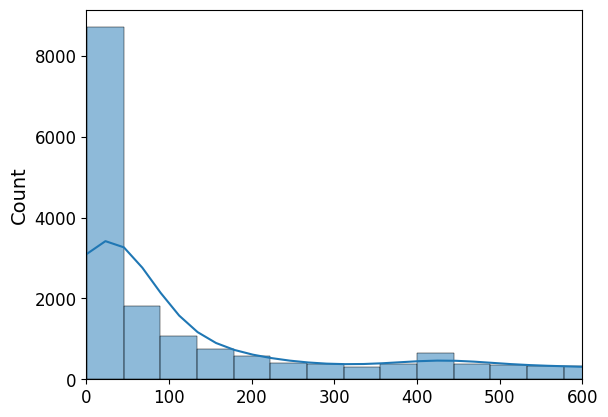

In [54]:
# Using seaborn's distplot for a more visual distribution plot
sns.histplot(anomaly_scores, kde=True, bins=100) 
plt.xlim(0,600) 
plt.show()

In [55]:
train_tag=datetime.datetime.now(pytz.timezone('Australia/Sydney')).strftime('%Y-%m-%d-%H-%M')

In [56]:
all_metrics_dfs = []
for thresh in range(100,600, 50):
        metrics, combined_df = networkEvaluator.evaluate(conf,model, data, all_nodes_df, 
                          thresh, train_tag, conf.artefact_path + "/metrics_train.csv", 
                          'New T2I', 'AUC-PR')
                # Convert metrics dict to DataFrame (assuming keys are the metric names)
        metrics_df = pd.DataFrame([metrics])
        
        # Add a column for the threshold to track which metrics belong to which threshold
        metrics_df['threshold'] = thresh
        # Append the DataFrame to the list
        all_metrics_dfs.append(metrics_df)
# Concatenate all the DataFrames into a single DataFrame
combined_metrics_df = pd.concat(all_metrics_dfs, ignore_index=True)

Evaluation Metrics:
alert_vol: 8293
Precision: 0.012902447847582299
Recall: 0.8106060606060606
F1 Score: 0.02540059347181009
Confusion Matrix: [[10822  8186]
 [   25   107]]
AUC-PR: 0.02216811728275935
AUC-ROC: 0.7649378889909193
Current T2I: 0.10015174506828528
New T2I: 0.13932291666666666
Evaluation Metrics:
alert_vol: 7250
Precision: 0.01406896551724138
Recall: 0.7727272727272727
F1 Score: 0.02763478732050935
Confusion Matrix: [[11860  7148]
 [   30   102]]
AUC-PR: 0.02216811728275935
AUC-ROC: 0.7649378889909193
Current T2I: 0.10015174506828528
New T2I: 0.14782608695652175
Evaluation Metrics:
alert_vol: 6518
Precision: 0.015495550782448604
Recall: 0.7651515151515151
F1 Score: 0.030375939849624063
Confusion Matrix: [[12591  6417]
 [   31   101]]
AUC-PR: 0.02216811728275935
AUC-ROC: 0.7649378889909193
Current T2I: 0.10015174506828528
New T2I: 0.1650326797385621
Evaluation Metrics:
alert_vol: 5951
Precision: 0.01646782053436397
Recall: 0.7424242424242424
F1 Score: 0.03222094361334867
C

In [57]:
combined_metrics_df

,alert_vol,Precision,Recall,F1 Score,Confusion Matrix,AUC-PR,AUC-ROC,Current T2I,New T2I,threshold
0,8293,0.013,0.811,0.025,"[[10822, 8186], [25, 107]]",0.022,0.765,0.10015174506828528,0.13932291666666666,100
1,7250,0.014,0.773,0.028,"[[11860, 7148], [30, 102]]",0.022,0.765,0.10015174506828528,0.14782608695652175,150
2,6518,0.015,0.765,0.030,"[[12591, 6417], [31, 101]]",0.022,0.765,0.10015174506828528,0.1650326797385621,200
3,5951,0.016,0.742,0.032,"[[13155, 5853], [34, 98]]",0.022,0.765,0.10015174506828528,0.1785063752276867,250
4,5541,0.017,0.727,0.034,"[[13563, 5445], [36, 96]]",0.022,0.765,0.10015174506828528,0.1875,300
5,5197,0.018,0.697,0.035,"[[13903, 5105], [40, 92]]",0.022,0.765,0.10015174506828528,0.19327731092436976,350
6,4763,0.019,0.682,0.037,"[[14335, 4673], [42, 90]]",0.022,0.765,0.10015174506828528,0.20833333333333334,400
7,4037,0.021,0.636,0.040,"[[15055, 3953], [48, 84]]",0.022,0.765,0.10015174506828528,0.21374045801526717,450
8,3639,0.022,0.614,0.043,"[[15450, 3558], [51, 81]]",0.022,0.765,0.10015174506828528,0.22816901408450704,500
9,3245,0.024,0.591,0.046,"[[15841, 3167], [54, 78]]",0.022,0.765,0.10015174506828528,0.24148606811145512,550


In [58]:
y_emb

tensor([[ 23.8562, 194.2575,   0.0000,  ...,   0.0000, 132.4247, 139.0641],
        [ 33.0826, 129.3175,   0.0000,  ...,  30.7585,  59.1333,  40.0776],
        [  0.0000,  36.9434,   0.0000,  ...,   0.0000,  13.3378,   8.3633],
        ...,
        [  2.2267,   7.4637,   0.0000,  ...,   2.7013,   6.1582,   6.5943],
        [ 42.9096, 117.1961,   0.0000,  ...,  23.6409, 109.7999, 118.1824],
        [ 32.2967,  89.4533,   0.0000,  ...,   9.7731,  70.9063,  95.6321]])

ROC-AUC: 0.76


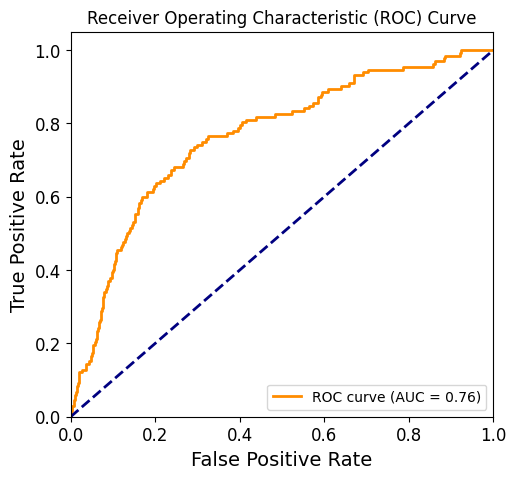

In [59]:
# ROC Curve
y_score=anomaly_scores
fpr, tpr, _ = roc_curve(y, y_score)  # Get False Positive Rate, True Positive Rate
roc_auc = auc(fpr, tpr)  # Calculate ROC AUC

# PR Curve
precision, recall, _ = precision_recall_curve(y, y_score)
pr_auc = auc(recall, precision)  # Calculate PR AUC

# Print the AUC values
print(f'ROC-AUC: {roc_auc:.2f}')
# print(f'PR-AUC: {pr_auc:.2f}')

# Plot ROC curve
plt.figure(figsize=(12, 5))

# ROC curve
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# # PR curve
# plt.subplot(1, 2, 2)
# plt.plot(recall, precision, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc:.2f})')
# plt.xlim([0.0, 1.0])
# plt.ylim([0.0, 1.05])
# plt.xlabel('Recall')
# plt.ylabel('Precision')
# plt.title('Precision-Recall (PR) Curve')
# plt.legend(loc="lower left")

# plt.tight_layout()
# plt.show()

In [60]:
# Identify Top-K Anomalous Nodes
topk = int(data.x.size(0)*0.01)  # Adjust as needed
_, topk_indices = torch.topk(anomaly_scores, k=topk, largest=True)
print(f'Top-{topk} anomalous nodes: {topk_indices}')

Top-191 anomalous nodes: tensor([ 4564,  2277,  4416,  3263,  2757,    32,  7134,  6942,  9203,  9926,
         8209,  8475,  7956, 10646,  8142,  2324,  7400,  7997,  3898, 16807,
         4290,  8611,  3369,  8009, 10097,   193,  6784,  7340,  4952,    59,
         4538,  3542,  7840,  4517,   712,  9832,  2057,  4634,  6853,  4018,
         8221, 11183,  5517,  2217, 10793,  9079,  4752,  6357,  2228,  6462,
         9220,  8280, 12092,  8692,  3443,  5016,  7834,  2739,  2053,  7192,
         4578,  2346,    88,  5660, 10120,  9370,  5575,  1765,  2736,  4241,
        12704,   192,  9154,  5014,  3541,  3758,   155,  7081,  2375,  2111,
         5698,  9905,   161, 10173,  3241,  8558,  5555,  5873,  9859,  5099,
         3056, 12970,  3750,   572, 12029,  3292,  3510,  7533,  5025,  7383,
         6074,  7647, 12848,  2866,  7802,  1505,  4352,  1792, 10478,  3845,
         4233,  7118, 11728,  2569, 13265,  5766,  3782,  3733,  7507,  2131,
         8411,  4632,  1654,  2018,  69

In [61]:
# # Invert the mapping to get indices back to node IDs
# idx_to_node_id = {idx: node_id for node_id, idx in node_id_to_idx.items()}

# # Now, get the node IDs of the top-K anomalous nodes
# topk_node_ids = [idx_to_node_id[idx.item()] for idx in topk_indices]

# print(f'Top-{topk} anomalous node IDs: {topk_node_ids}')

### 3.3 Claim Clustering 

In [62]:
import numpy as np
from sklearn.cluster import OPTICS
# Create and fit the OPTICS model
x_cluster = y_emb.detach().numpy()
# optics_model = OPTICS(min_samples=2, max_eps=0.01, xi=0.01, min_cluster_size=0.01)
optics_model = OPTICS(min_samples=5, xi=0.01, min_cluster_size=0.0001)
optics_model.fit(x_cluster)

c:\Users\s745998\AppData\Local\miniconda3\envs\mygraphenv\lib\site-packages\sklearn\cluster\_optics.py:995: RuntimeWarning: divide by zero encountered in divide
  ratio = reachability_plot[:-1] / reachability_plot[1:]


OPTICS(min_cluster_size=0.0001, xi=0.01)

In [63]:
from sklearn.cluster import DBSCAN

# Convert the PyTorch tensor 'y_emb' to a NumPy array
x_cluster = y_emb.detach().numpy()

# Create and fit the DBSCAN model
# dbscan_model = DBSCAN(eps=0.05, min_samples=5)  # Adjust `eps` based on your data
dbscan_model = DBSCAN(eps=0.05, min_samples=5)  # Adjust `eps` based on your data
# Fit the model to your data
dbscan_model.fit(x_cluster)

DBSCAN(eps=0.05)

In [64]:
# extract cluster labels
#cluster_labels = optics_model.labels_
cluster_labels = dbscan_model.labels_
cluster_labels

array([ 0, -1, -1, ..., -1, -1, -1], dtype=int64)

In [65]:
# Get unique values and their counts
unique_values, counts = np.unique(cluster_labels, return_counts=True)

# Display results
for value, count in zip(unique_values, counts):
    print(f'Value: {value}, Count: {count}')

Value: -1, Count: 17962
Value: 0, Count: 7
Value: 1, Count: 519
Value: 2, Count: 38
Value: 3, Count: 44
Value: 4, Count: 148
Value: 5, Count: 6
Value: 6, Count: 10
Value: 7, Count: 24
Value: 8, Count: 5
Value: 9, Count: 8
Value: 10, Count: 5
Value: 11, Count: 35
Value: 12, Count: 5
Value: 13, Count: 11
Value: 14, Count: 30
Value: 15, Count: 7
Value: 16, Count: 5
Value: 17, Count: 5
Value: 18, Count: 5
Value: 19, Count: 30
Value: 20, Count: 5
Value: 21, Count: 5
Value: 22, Count: 14
Value: 23, Count: 6
Value: 24, Count: 6
Value: 25, Count: 7
Value: 26, Count: 5
Value: 27, Count: 6
Value: 28, Count: 11
Value: 29, Count: 21
Value: 30, Count: 5
Value: 31, Count: 8
Value: 32, Count: 9
Value: 33, Count: 5
Value: 34, Count: 7
Value: 35, Count: 8
Value: 36, Count: 18
Value: 37, Count: 8
Value: 38, Count: 11
Value: 39, Count: 6
Value: 40, Count: 14
Value: 41, Count: 5
Value: 42, Count: 10
Value: 43, Count: 26
Value: 44, Count: 5


In [66]:
# #Calculate Node Degrees
# from torch_geometric.utils import degree

# edge_index = data.edge_index
# num_nodes = data.num_nodes

# # Calculate the degree of each node
# node_degrees = degree(edge_index[0], num_nodes=num_nodes)


In [67]:
# # Use the cluster labels to group nodes into clusters and compute their respective degrees
# from collections import defaultdict

# # Create a dictionary to store node degrees for each cluster
# cluster_degrees = defaultdict(list)

# cluster_indices = defaultdict(list)

# cluster_nodes = defaultdict(list)

# # Iterate over all nodes and add their degrees to the corresponding cluster
# for node_idx in range(num_nodes):
#     cluster_label = cluster_labels[node_idx].item()
#     cluster_degrees[cluster_label].append(node_degrees[node_idx].item())
#     cluster_indices[cluster_label].append(node_idx)
#     cluster_nodes[cluster_label].append(G.nodes()[node_idx])

In [68]:
# Use the cluster labels to group nodes into clusters and compute their respective degrees
from collections import defaultdict
cluster_nodes = defaultdict(list)

for node, label in zip(G.nodes(), cluster_labels):
        cluster_nodes[label].append(node)


In [69]:
average_degrees = {}

for idx, cluster in cluster_nodes.items():
        subG = G.subgraph(cluster)
        subgraph_degrees = dict(subG.degree())
        average_degree = sum(subgraph_degrees.values()) / len(subgraph_degrees)
        average_degrees[idx] = (average_degree)

for cluster_label, avg_degree in average_degrees.items():
    print(f'Average degree of cluster {cluster_label}: {avg_degree:.2f}')

Average degree of cluster 0: 6.00
Average degree of cluster -1: 2.62
Average degree of cluster 1: 518.00
Average degree of cluster 2: 37.00
Average degree of cluster 3: 43.00
Average degree of cluster 4: 147.00
Average degree of cluster 5: 5.00
Average degree of cluster 6: 9.00
Average degree of cluster 7: 23.00
Average degree of cluster 8: 4.00
Average degree of cluster 9: 7.00
Average degree of cluster 10: 4.00
Average degree of cluster 11: 34.00
Average degree of cluster 12: 4.00
Average degree of cluster 13: 10.00
Average degree of cluster 14: 29.00
Average degree of cluster 15: 6.00
Average degree of cluster 16: 4.00
Average degree of cluster 17: 4.00
Average degree of cluster 18: 4.00
Average degree of cluster 19: 29.00
Average degree of cluster 20: 4.00
Average degree of cluster 21: 4.00
Average degree of cluster 22: 0.00
Average degree of cluster 23: 5.00
Average degree of cluster 24: 5.00
Average degree of cluster 25: 6.00
Average degree of cluster 26: 0.00
Average degree of c

In [70]:
graph_degrees = dict(G.degree())
global_avg=sum(graph_degrees.values()) / len(graph_degrees)
global_avg

26.776280041797282

In [71]:
filtered_cluster = {cluster_label: avg_degree for cluster_label, avg_degree in average_degrees.items() if avg_degree > global_avg}

# Print or use the filtered clusters as needed
for cluster_label, avg_degree in filtered_cluster.items():
    print(f'Cluster {cluster_label} has an average degree {avg_degree:.2f}, which is larger than the global average.')

Cluster 1 has an average degree 518.00, which is larger than the global average.
Cluster 2 has an average degree 37.00, which is larger than the global average.
Cluster 3 has an average degree 43.00, which is larger than the global average.
Cluster 4 has an average degree 147.00, which is larger than the global average.
Cluster 11 has an average degree 34.00, which is larger than the global average.
Cluster 14 has an average degree 29.00, which is larger than the global average.
Cluster 19 has an average degree 29.00, which is larger than the global average.


In [72]:
# Sort the filtered clusters by average degree in descending order
ranked_filtered_cluster = dict(sorted(filtered_cluster.items(), key=lambda item: item[1], reverse=True))

# Print or use the ranked clusters as needed
for cluster_label, avg_degree in ranked_filtered_cluster.items():
    print(f'Cluster {cluster_label} has an average degree {avg_degree:.2f}, which is larger than the global average.')


Cluster 1 has an average degree 518.00, which is larger than the global average.
Cluster 4 has an average degree 147.00, which is larger than the global average.
Cluster 3 has an average degree 43.00, which is larger than the global average.
Cluster 2 has an average degree 37.00, which is larger than the global average.
Cluster 11 has an average degree 34.00, which is larger than the global average.
Cluster 14 has an average degree 29.00, which is larger than the global average.
Cluster 19 has an average degree 29.00, which is larger than the global average.


In [73]:
def visualize_subgraph(G, cluster_nodes, label):
  
    # Create a subgraph containing only the nodes in the cluster
    subgraph = G.subgraph(cluster_nodes[label])
    size=len(cluster_nodes[label])
    average_degree1=average_degrees[label]
    print(f'the size of the cluster (the claim nodes included) is {size}')
    print(f'the average connection for each node is {average_degree1}')
    
    # Create a color map for nodes based on an attribute 'y'
    color_map = []
    for node in subgraph.nodes(data=True):
        if node[1].get('y') == 1:
            color_map.append('red')
        else:
            color_map.append('skyblue')
    
    # Draw the subgraph
    pos = nx.spring_layout(subgraph)  # You can change the layout as needed
    plt.figure(figsize=(8, 6))
    nx.draw(subgraph, pos, with_labels=False, node_color=color_map, edge_color='grey', node_size=100, font_size=10)
    plt.title(f'Subgraph for Cluster {label}')
    plt.show()

the size of the cluster (the claim nodes included) is 17962
the average connection for each node is 2.6207549270682553


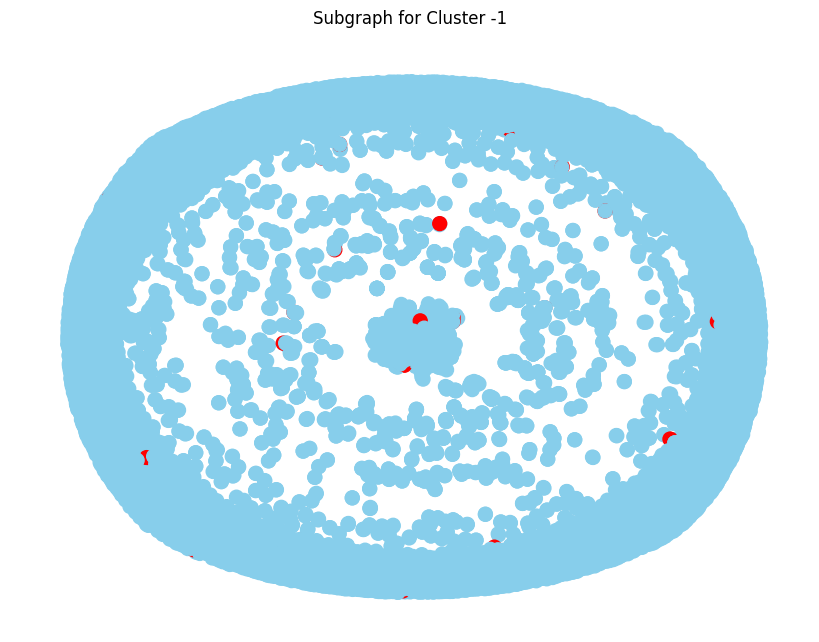

In [74]:
visualize_subgraph(G, cluster_nodes, -1)

the size of the cluster (the claim nodes included) is 148
the average connection for each node is 147.0


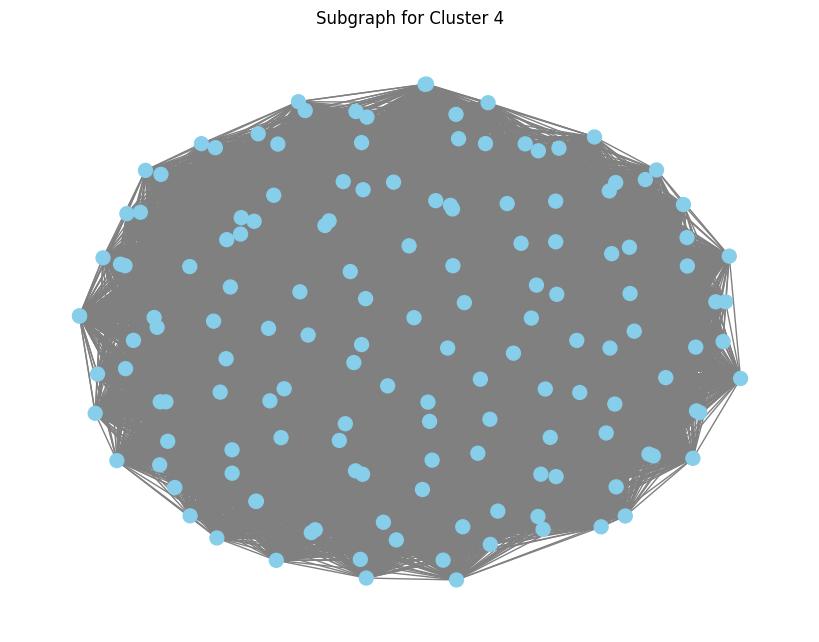

In [75]:
visualize_subgraph(G, cluster_nodes, 4)

the size of the cluster (the claim nodes included) is 38
the average connection for each node is 37.0


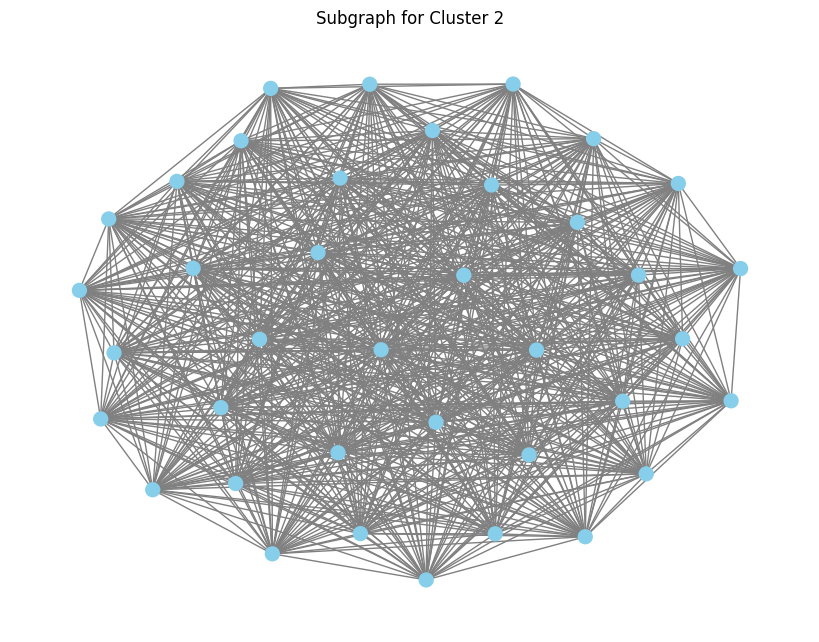

In [76]:
visualize_subgraph(G, cluster_nodes, 2)

the size of the cluster (the claim nodes included) is 5
the average connection for each node is 4.0


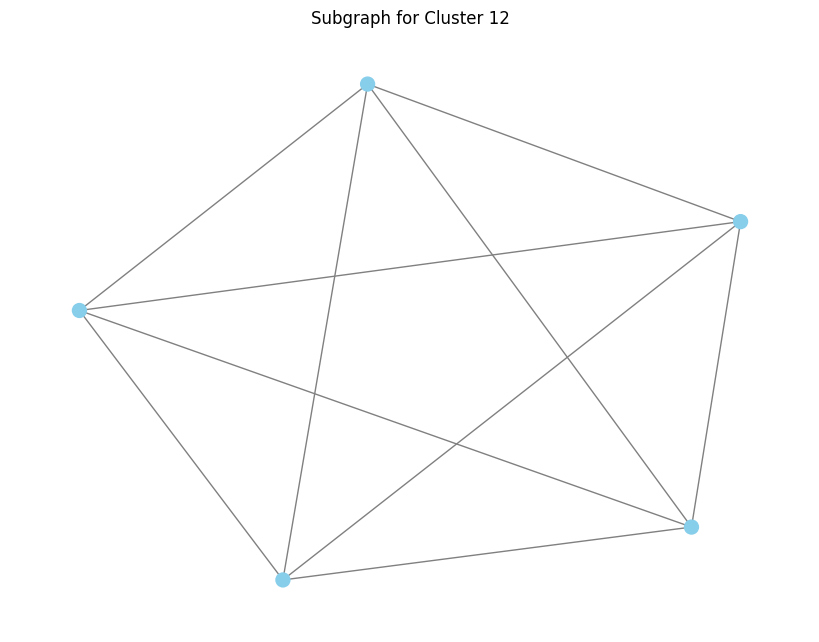

In [77]:
visualize_subgraph(G, cluster_nodes, 12)

the size of the cluster (the claim nodes included) is 30
the average connection for each node is 29.0


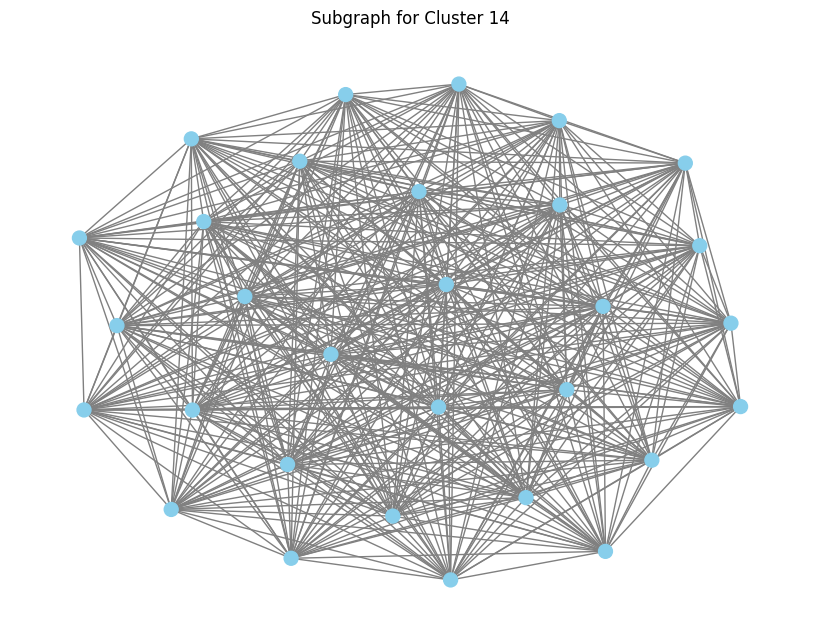

In [78]:
visualize_subgraph(G, cluster_nodes, 14)

the size of the cluster (the claim nodes included) is 5
the average connection for each node is 0.0


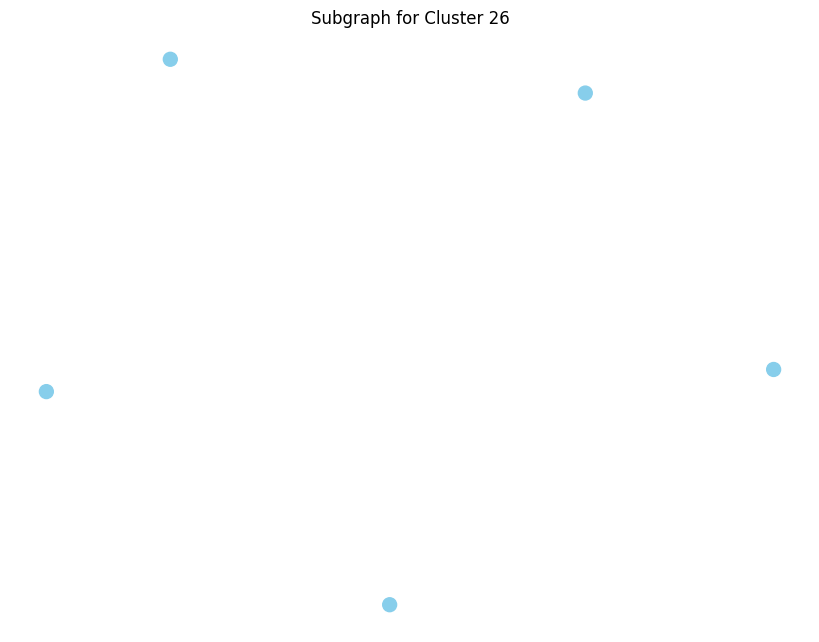

In [79]:
visualize_subgraph(G, cluster_nodes, 26)

the size of the cluster (the claim nodes included) is 8
the average connection for each node is 7.0


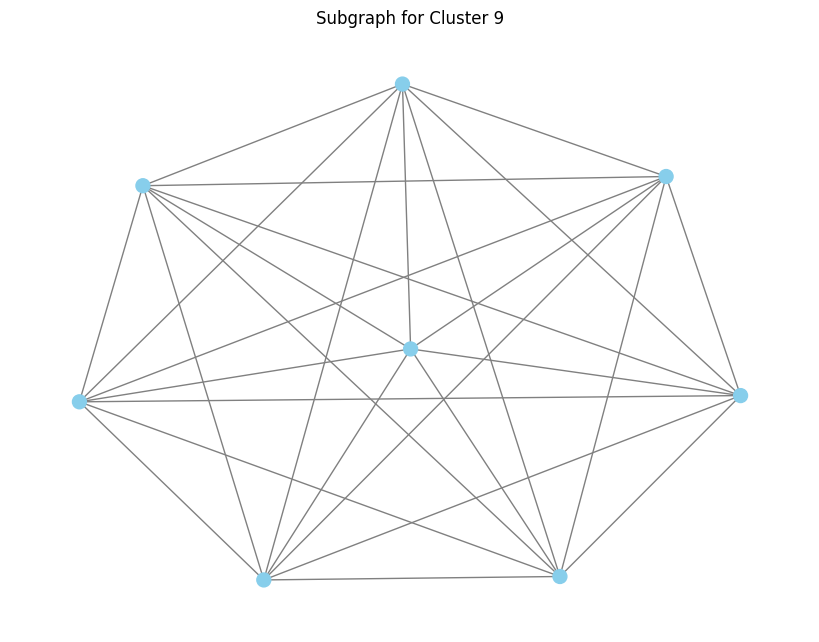

In [80]:
visualize_subgraph(G, cluster_nodes, 9)

### Graph Analysis

In [81]:
nodes_with_y_1 = [n for n, attr in G.nodes(data=True) if attr.get("y") == 1]

Nodes in the subgraph: [(16900, {'x': [58.0, 58.0, 0.0, 1.0, 0.0, 1.0, 0.0, 351.0, 10.0, 0.0, 0.0, 1.0, 0.0, 224.0, 1.0, 1.0, 0.0, 0.0, 345.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0], 'y': 1}), (15367, {'x': [22.0, 22.0, 0.0, 1.0, 0.0, 1.0, 1.0, 181.0, 7.0, 0.0, 0.0, 0.0, 0.0, 367.0, 1.0, 1.0, 0.0, 0.0, 516.0, 0.0, 2711.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0], 'y': 1}), (11801, {'x': [18.0, 18.0, 0.0, 0.0, 0.0, 1.0, 0.0, 182.0, 13.0, 0.0, 0.0, 0.0, 0.0, 115.0, 0.0, 0.0, 0.0, 0.0, 902.0, 0.0, 657.030029296875, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0], 'y': 1}), (10271, {'x': [8.0, 8.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1240.0, 32.0, 0.0, 0.0, 0.0, 0.0, 433.0, 1.0, 1.0, 1.0, 0.0, 1147.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0], 'y': 1}), (15392, {'x': [16.0, 16.0, 0.0, 0.0, 1.0, 1.0, 0.0, 181.0, 15.0, 0.0, 0.0, 0.0, 0.0, 7.0, 0.0, 0.0, 1.0, 0.0, 536.0, 1.0, 1955.8599853515625, 1.0, 1.0, 0.0, 1.0, 21.0, 0.0, 0.0, 1.0], 'y': 1}), (3111, {'x': [4.0, 4.0, 0.0, 0.0, 0.0, 1.0, 1.0

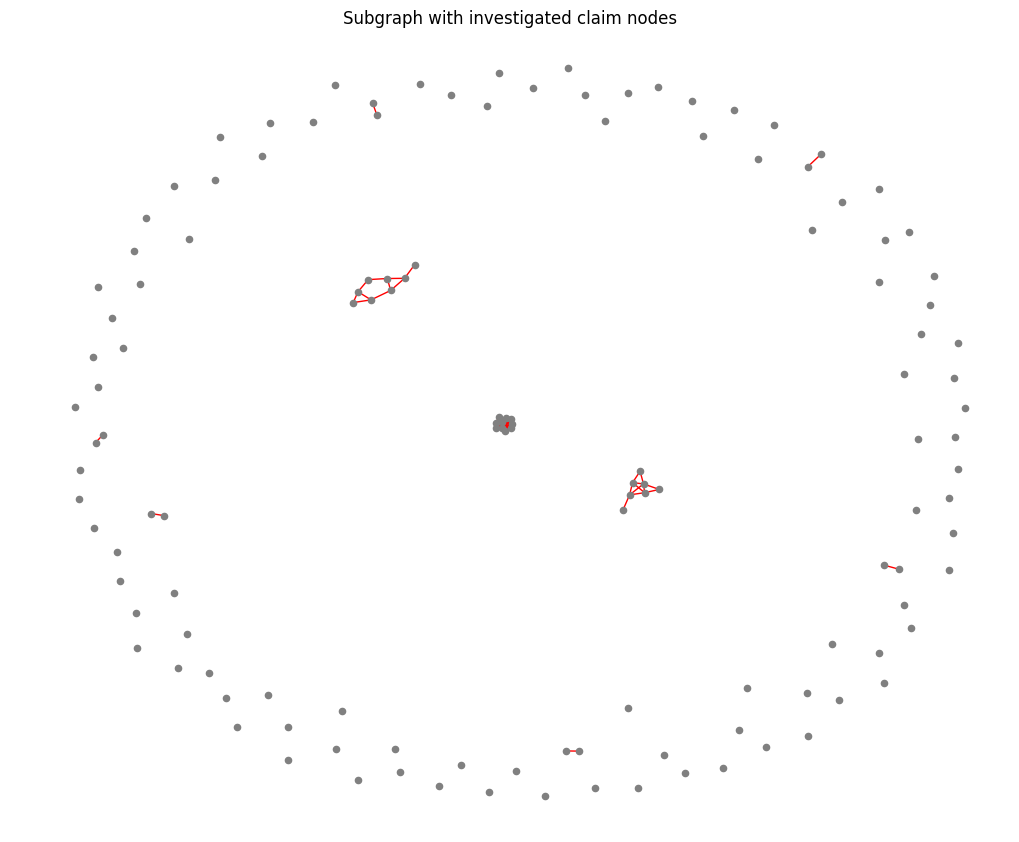

In [82]:
subG = G.subgraph(nodes_with_y_1)

# Output the nodes and edges of the subgraph
print(f"Nodes in the subgraph: {subG.nodes(data=True)}")
print(f"Edges in the subgraph: {subG.edges()}")

# Draw the subgraph
pos = nx.spring_layout(subG)  # You can change the layout as needed
# pos = nx.kamada_kawai_layout(subG)
plt.figure(figsize=(10, 8))
nx.draw(subG, pos, with_labels=False, node_color='grey', edge_color='red', node_size=20, font_size=8)
plt.title(f'Subgraph with investigated claim nodes')
plt.show()

In [83]:
# subgraph_degrees_red = dict(subG.degree())
# subgraph_degrees

In [84]:
from networkx.algorithms.community import greedy_modularity_communities

# Find the communities using greedy modularity maximization
communities = greedy_modularity_communities(subG)

# Convert the result to a list of sets of nodes
communities = list(communities)
for i, community in enumerate(communities):
    print(f"Community {i+1}: {community}")

Community 1: frozenset({834, 259, 554, 1197, 749, 1425, 82, 116, 1373, 159})
Community 2: frozenset({12740, 14761, 17259, 14445, 14576, 9841, 14905, 14491})
Community 3: frozenset({12976, 12753, 12722, 14530, 14504, 5755, 13231})
Community 4: frozenset({16900, 9517})
Community 5: frozenset({13908, 5831})
Community 6: frozenset({16346, 19050})
Community 7: frozenset({6460, 8558})
Community 8: frozenset({14224, 13711})
Community 9: frozenset({10625, 10675})
Community 10: frozenset({15367})
Community 11: frozenset({11801})
Community 12: frozenset({10271})
Community 13: frozenset({15392})
Community 14: frozenset({3111})
Community 15: frozenset({7207})
Community 16: frozenset({1590})
Community 17: frozenset({12855})
Community 18: frozenset({59})
Community 19: frozenset({10302})
Community 20: frozenset({3652})
Community 21: frozenset({7251})
Community 22: frozenset({4188})
Community 23: frozenset({6262})
Community 24: frozenset({4219})
Community 25: frozenset({6274})
Community 26: frozenset(

In [85]:
def visualize_community(G, communities, community_idx):
# Create a subgraph containing only the nodes in the cluster
    selected_community = communities[community_idx]
    community_subgraph = G.subgraph(selected_community)


    # Create a color map for nodes based on an attribute 'y'
    color_map = []
    for node in community_subgraph.nodes(data=True):
        if node[1].get('y') == 1:
            color_map.append('red')
        else:
            color_map.append('skyblue')
    
    # Plot the subgraph for the selected community
    pos = nx.spring_layout(community_subgraph)  # You can change the layout as needed
    plt.figure(figsize=(8, 6))
    nx.draw(community_subgraph, pos, with_labels=True, node_color=color_map, edge_color='grey', node_size=800, font_size=10)
    plt.title(f'Subgraph for Community {community_idx}')
    plt.show()

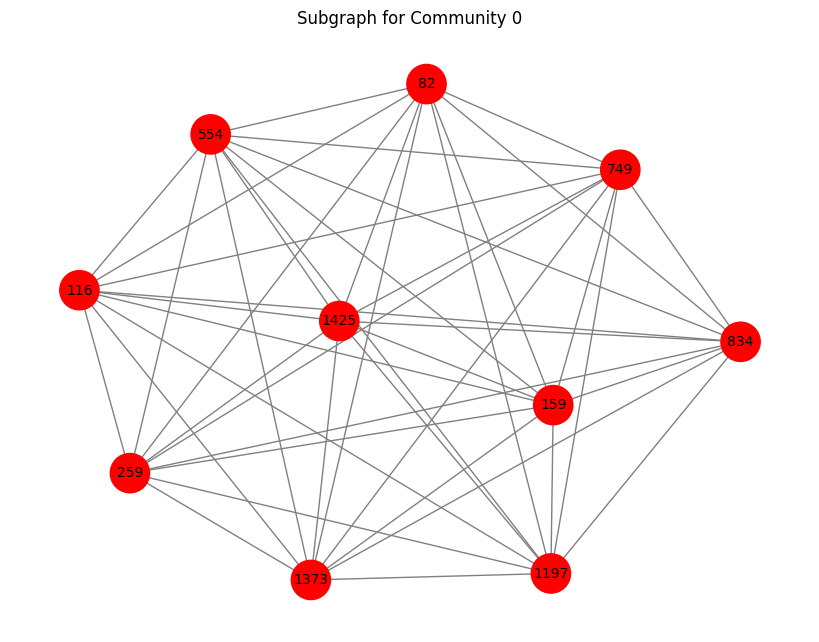

In [94]:
visualize_community(G, communities, 0)

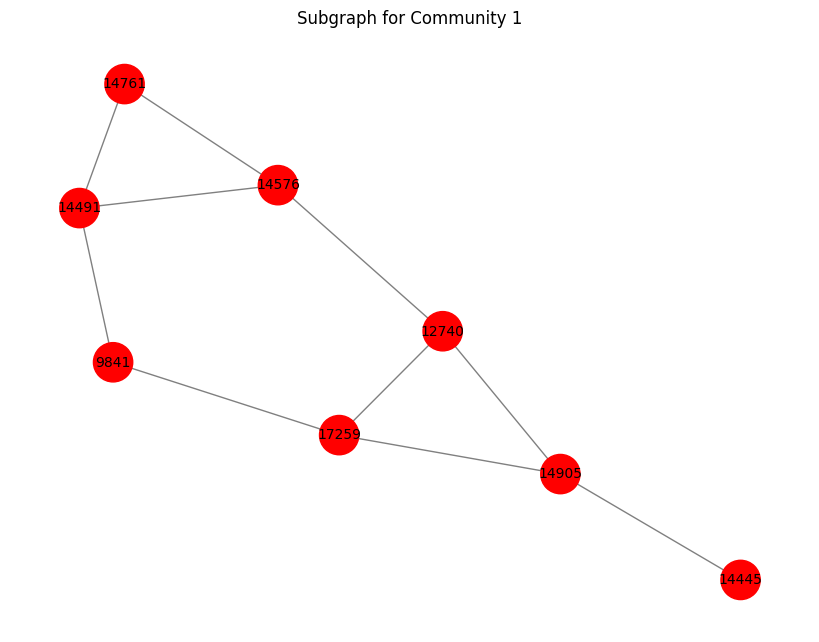

In [87]:
visualize_community(G, communities, 1)

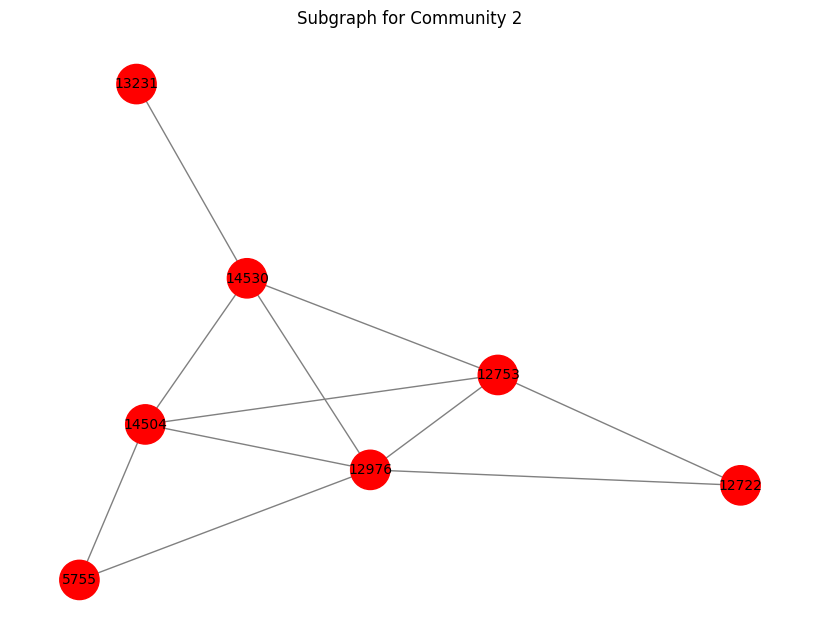

In [88]:
visualize_community(G, communities, 2)

# 4. Community detection

In [89]:
def recursive_community_detection(G, communities_list,resolution,threshold,seed_value=42):

    random.seed(seed_value)
    np.random.seed(seed_value)
    # If the graph has 50 or fewer nodes, append it to the final communities list
    if G.number_of_nodes() <= threshold:
        communities_list.append(set(G.nodes))
    else:
        # Perform community detection on the subgraph
        communities = nx.community.greedy_modularity_communities(G, weight='weight', resolution=resolution)
        
        # Apply the function recursively on the detected communities
        for community in communities:
            subgraph = G.subgraph(community)
            recursive_community_detection(subgraph, communities_list,resolution=resolution,threshold=threshold)

In [90]:
final_communities=[]

recursive_community_detection(G, final_communities, resolution=1.5, threshold=50)

In [114]:
len(final_communities)

15548

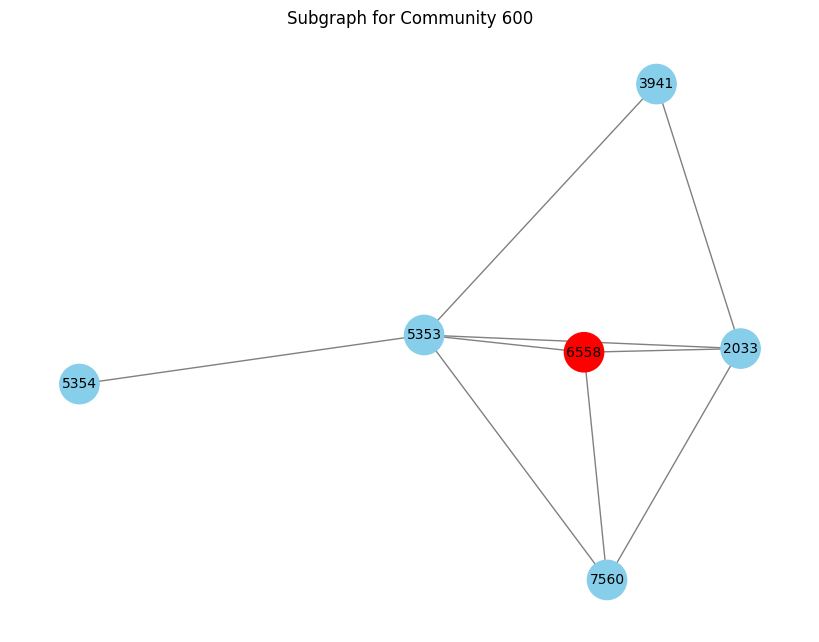

In [92]:
visualize_community(G, final_communities, 600 )

In [120]:
#assign score to the nodes in communities
# anomaly_scores=anomaly_scores.tolist()
cluster_scores = defaultdict(list)
# Iterating over each community and add anomaly scores
for i, community in enumerate(final_communities):
    for node in community:
        cluster_scores[i].append(anomaly_scores[node])

In [137]:
average_score_cluster = {}

for idx, score in cluster_scores.items():
        if len(score)>=5:
                average_score = sum(score) / len(score)
                average_score_cluster[idx] = (average_score)

for cluster_label, avg_score in average_score_cluster.items():
    print(f'Average anomaly score of cluster {cluster_label}: {avg_score:.2f}')

Average anomaly score of cluster 0: 695.69
Average anomaly score of cluster 1: 574.08
Average anomaly score of cluster 2: 655.21
Average anomaly score of cluster 3: 419.38
Average anomaly score of cluster 4: 705.95
Average anomaly score of cluster 14: 699.75
Average anomaly score of cluster 15: 817.68
Average anomaly score of cluster 16: 723.15
Average anomaly score of cluster 17: 572.52
Average anomaly score of cluster 18: 776.83
Average anomaly score of cluster 19: 801.96
Average anomaly score of cluster 20: 984.45
Average anomaly score of cluster 42: 639.66
Average anomaly score of cluster 43: 480.82
Average anomaly score of cluster 44: 558.73
Average anomaly score of cluster 45: 608.71
Average anomaly score of cluster 46: 509.69
Average anomaly score of cluster 47: 222.15
Average anomaly score of cluster 48: 342.37
Average anomaly score of cluster 49: 668.99
Average anomaly score of cluster 50: 349.89
Average anomaly score of cluster 51: 145.13
Average anomaly score of cluster 52: 

In [138]:
# Sort the filtered clusters by average degree in descending order
ranked_cluster = dict(sorted(average_score_cluster.items(), key=lambda item: item[1], reverse=True))

# Print or use the ranked clusters as needed
for cluster_label, avg_score in ranked_cluster.items():
    print(f'Cluster {cluster_label} has an average score {avg_score:.2f}, which is larger than the global average.')

Cluster 671 has an average score 1190.16, which is larger than the global average.
Cluster 665 has an average score 1097.64, which is larger than the global average.
Cluster 717 has an average score 1093.24, which is larger than the global average.
Cluster 723 has an average score 1032.10, which is larger than the global average.
Cluster 20 has an average score 984.45, which is larger than the global average.
Cluster 725 has an average score 903.86, which is larger than the global average.
Cluster 652 has an average score 885.19, which is larger than the global average.
Cluster 222 has an average score 875.12, which is larger than the global average.
Cluster 153 has an average score 871.32, which is larger than the global average.
Cluster 146 has an average score 854.49, which is larger than the global average.
Cluster 691 has an average score 845.80, which is larger than the global average.
Cluster 15 has an average score 817.68, which is larger than the global average.
Cluster 149 ha

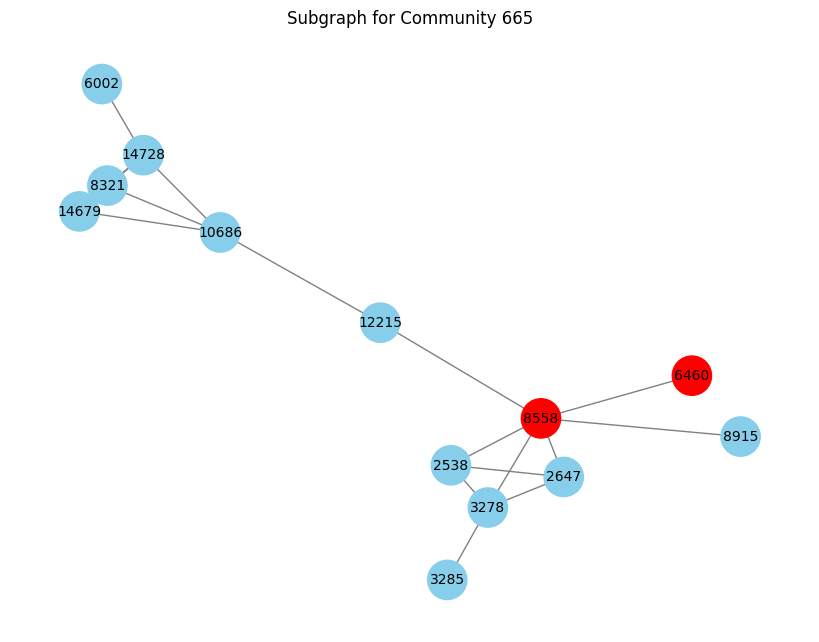

In [140]:
visualize_community(G, final_communities, 665)